In [ ]:
!pip install kaggle

In [ ]:
from google.colab import files
files.upload()


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"tanishk4567890","key":"6fca5bb6370238cabdd9ff3328327aa9"}'}

In [ ]:
!mkdir ~/.kaggle

In [ ]:
!cp kaggle.json ~/.kaggle/

In [ ]:
ls -ltr ~/.kaggle/

total 4
-rw-r--r-- 1 root root 70 May 25 17:30 kaggle.json


In [ ]:
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d 'salader/dogsvscats'

Dataset URL: https://www.kaggle.com/datasets/salader/dogsvscats
License(s): unknown
100% 1.06G/1.06G [01:04<00:00, 17.8MB/s]



In [ ]:
!unzip ../content/dogsvscats.zip -d ../content/

Streaming output truncated to the last 5000 lines.
  inflating: ../content/train/dogs/dog.4419.jpg  
  inflating: ../content/train/dogs/dog.442.jpg  
  inflating: ../content/train/dogs/dog.4420.jpg  
  inflating: ../content/train/dogs/dog.4421.jpg  
  inflating: ../content/train/dogs/dog.4422.jpg  
  inflating: ../content/train/dogs/dog.4424.jpg  
  inflating: ../content/train/dogs/dog.4425.jpg  
  inflating: ../content/train/dogs/dog.4426.jpg  
  inflating: ../content/train/dogs/dog.4427.jpg  
  inflating: ../content/train/dogs/dog.4431.jpg  
  inflating: ../content/train/dogs/dog.4433.jpg  
  inflating: ../content/train/dogs/dog.4436.jpg  
  inflating: ../content/train/dogs/dog.4438.jpg  
  inflating: ../content/train/dogs/dog.4439.jpg  
  inflating: ../content/train/dogs/dog.444.jpg  
  inflating: ../content/train/dogs/dog.4440.jpg  
  inflating: ../content/train/dogs/dog.4441.jpg  
  inflating: ../content/train/dogs/dog.4442.jpg  
  inflating: ../content/train/dogs/dog.4443.jpg  
 

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, Flatten, MaxPooling2D, Dense, BatchNormalization

In [ ]:
train_ds = keras.utils.image_dataset_from_directory(
    directory='/content/catsvsdogs/train',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256,256)
)

valid_ds = keras.utils.image_dataset_from_directory(
    directory='/content/catsvsdogs/test',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256,256)
)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


In [ ]:
print(train_ds.class_names)

['cats', 'dogs']


In [ ]:
def process(image, label):
  image = tf.cast(image/255. ,tf.float32)
  return image, label

train_ds = train_ds.map(process)
valid_ds=valid_ds.map(process)

In [ ]:
model=Sequential()

model.add(Conv2D(32, kernel_size=(3,3), padding='valid', activation='relu', input_shape=(256,256,3)))
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Conv2D(64, kernel_size=(3,3), padding='valid', activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Conv2D(128, kernel_size=(3,3), padding='valid', activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,297 (56.64 MB)

 Trainable params: 14,847,297 (56.64 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [ ]:
log=model.fit(train_ds, epochs=10, validation_data=(valid_ds))

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 61s 78ms/step - accuracy: 0.6684 - loss: 0.5975 - val_accuracy: 0.7732 - val_loss: 0.4841
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 51s 82ms/step - accuracy: 0.7846 - loss: 0.4538 - val_accuracy: 0.7860 - val_loss: 0.4602
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 52s 83ms/step - accuracy: 0.8388 - loss: 0.3533 - val_accuracy: 0.7810 - val_loss: 0.4693
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 53s 85ms/step - accuracy: 0.9026 - loss: 0.2291 - val_accuracy: 0.7806 - val_loss: 0.5428
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 49s 78ms/step - accuracy: 0.9488 - loss: 0.1321 - val_accuracy: 0.7952 - val_loss: 0.7467
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 79ms/step - accuracy: 0.9674 - loss: 0.0888 - val_accuracy: 0.7936 - val_loss: 0.8505
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 52s 83ms/step - accuracy: 0.9780 - loss: 0.0605 - val_accuracy: 0.7976 - val_loss: 0.8961
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 49s 78ms/step - accuracy: 0.9836 - loss: 0.0493 - 

In [ ]:
import matplotlib.pyplot as plt


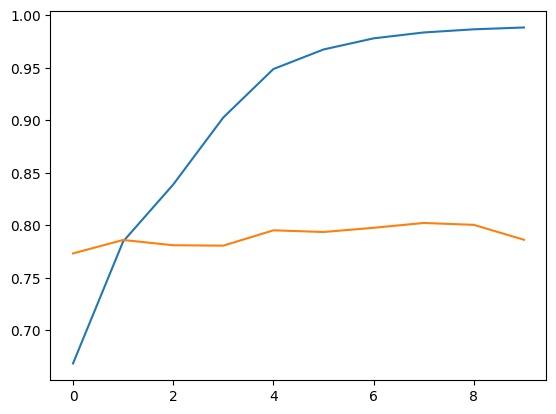

In [ ]:
plt.plot(log.history['accuracy'])
plt.plot(log.history['val_accuracy'])

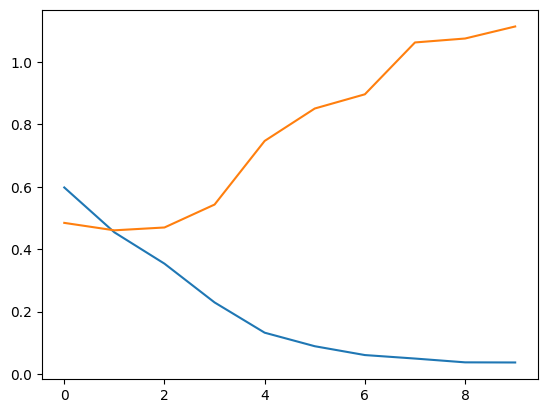

In [ ]:
plt.plot(log.history['loss'])
plt.plot(log.history['val_loss'])